# Implementation of biLSTM

In [1]:
from tensorflow.python.client import device_lib
print("\n".join([x.name for x in device_lib.list_local_devices()]))


/device:CPU:0
/device:GPU:0


## Load required libraries

In [8]:
import random, numpy as np, tensorflow as tf
import os
import sys
sys.path.append("../preprocessing")
from augmenter import Augmenter

import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import random
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Set global seed to control randomness

In [11]:
pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

# Set the random seed for TensorFlow operations
tf.config.experimental.enable_op_determinism()

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Preprocessing

In [3]:

data = np.load("../preprocessing/ready/squat_sequences__normalized.npz")

X_data = data["X"]
y_labels = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seeds[0]
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

print(y_test)

'''
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]
'''

(201, 189, 6) (51, 189, 6) (201,) (51,)
(189, 6) (189, 6) 1 0
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]


'\n[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0\n 0 0 0 1 0 0 1 1 1 0 1 1 0 0]\n'

# Processing with augmented Data

In [ ]:
# Load preprocessed augmented train/test sets
data = np.load("../preprocessing/ready/squat_sequences__normalized.npz")
X_data, y_labels = data["X"], data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seeds[0]
)

# Use the augmenter class
augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)
X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seeds[0])

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

print(y_test)



(603, 189, 6) (51, 189, 6) (603,) (51,)
(189, 6) (189, 6) 1 0
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]


# Defined model Function

In [4]:


def make_model_builder(input_shape):
    def build_model(lstm_units=64, dropout_rate=0.2, learning_rate=0.001):
        model = Sequential([
            Input(shape=input_shape),
            Masking(mask_value=0.0),
            Bidirectional(LSTM(lstm_units, return_sequences=True)),
            GlobalMaxPooling1D(),
            Dropout(dropout_rate),
            Dense(1, activation="sigmoid")
        ])
        model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
        return model
    return build_model

# Grid search with 5-fold cross validation

In [5]:
# Create the model builder using your actual input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Wrap for sklearn compatibility
bilstm_clf = KerasClassifier(
    model=model_builder,
    batch_size=32,  # fixed based on good past results
    verbose=0       # silent training
)

# Define hyperparameter grid, now including epochs too!
param_grid = {
    "model__lstm_units": [64, 96, 128],
    "model__dropout_rate": [0.2, 0.3, 0.4],
    "model__learning_rate": [0.0003, 0.0005],
    "epochs": [50, 100, 150]
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Grid search setup
grid_search = GridSearchCV(
    estimator=bilstm_clf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=2,   # Set to -1 for full parallelization if your CPU allows
    verbose=2
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Print best results
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\Marteinn\miniconda3\envs\tf-gpu\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Best Parameters: {'epochs': 150, 'model__dropout_rate': 0.4, 'model__learning_rate': 0.0003, 'model__lstm_units': 96}
✅ Best Cross-Validated Accuracy: 0.9851
    mean_test_score  std_test_score  \
49         0.985124        0.019835   
16         0.985096        0.008103   
47         0.983471        0.018107   
53         0.981804        0.024733   
28         0.981804        0.019126   

                                               params  
49  {'epochs': 150, 'model__dropout_rate': 0.4, 'm...  
16  {'epochs': 50, 'model__dropout_rate': 0.4, 'mo...  
47  {'epochs': 150, 'model__dropout_rate': 0.3, 'm...  
53  {'epochs': 150, 'model__dropout_rate': 0.4, 'm...  
28  {'epochs': 100, 'model__dropout_rate': 0.3, 'm...  


# Train the final model with the best hyperparameters

In [9]:
# Manually define a config you want to test
fixed_config = {
    "lstm_units": 96,
    "dropout_rate": 0.3,
    "learning_rate": 0.0003,
    "epochs": 100,
    "batch_size": 32
}

# Create builder with correct input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Call the returned function with best params
final_model = model_builder(
    lstm_units=fixed_config["lstm_units"],
    dropout_rate=fixed_config["dropout_rate"],
    learning_rate=fixed_config["learning_rate"]
)


# Train on the entire training set with the best params.
history = final_model.fit(
    X_train, y_train,
    epochs=fixed_config["epochs"],
    batch_size=fixed_config["batch_size"],
    verbose=1
)

# Evaluate on held-out test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final test accuracy: {test_accuracy:.4f}")


Epoch 1/100
7/7 [==============================] - 12s 47ms/step - loss: 0.6968 - accuracy: 0.4826
Epoch 2/100
7/7 [==============================] - 0s 35ms/step - loss: 0.6926 - accuracy: 0.4826
Epoch 3/100
7/7 [==============================] - 0s 33ms/step - loss: 0.6870 - accuracy: 0.5672
Epoch 4/100
7/7 [==============================] - 0s 33ms/step - loss: 0.6823 - accuracy: 0.5871
Epoch 5/100
7/7 [==============================] - 0s 34ms/step - loss: 0.6845 - accuracy: 0.5871
Epoch 6/100
7/7 [==============================] - 0s 34ms/step - loss: 0.6778 - accuracy: 0.6269
Epoch 7/100
7/7 [==============================] - 0s 35ms/step - loss: 0.6758 - accuracy: 0.6119
Epoch 8/100
7/7 [==============================] - 0s 33ms/step - loss: 0.6747 - accuracy: 0.6119
Epoch 9/100
7/7 [==============================] - 0s 36ms/step - loss: 0.6731 - accuracy: 0.6219
Epoch 10/100
7/7 [==============================] - 0s 35ms/step - loss: 0.6680 - accuracy: 0.7015
Epoch 11/100
7/7 [

# Save the model for reproducability

In [10]:
# Saving the model
final_model.save("best_model.h5")

# Evaluation

In [7]:
from collections import defaultdict
from tensorflow.keras.models import load_model

# Store metrics
results = defaultdict(list)

# Evaluate on test sets created with different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit to get test set (ignore training part)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )

    # Use the augmenter class
    #augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)
    #X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seed)

    # Manually define a config you want to test
    fixed_config = {
        "lstm_units": 96,
        "dropout_rate": 0.3,
        "learning_rate": 0.0003,
        "epochs": 100,
        "batch_size": 32
    }

    # Create builder with correct input shape
    model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

    # Call the returned function with best params
    final_model = model_builder(
        lstm_units=fixed_config["lstm_units"],
        dropout_rate=fixed_config["dropout_rate"],
        learning_rate=fixed_config["learning_rate"]
    )


    # Train on the entire training set with the best params.
    history = final_model.fit(
        X_train, y_train,
        epochs=fixed_config["epochs"],
        batch_size=fixed_config["batch_size"],
        verbose=1
    )
    
    # Predict and evaluate
    y_pred_probs = final_model.predict(X_test).flatten()
    y_pred = (y_pred_probs > 0.5).astype("int")

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs)

    # Store key metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])


# Print summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Print confusion matrix components
# Average confusion matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n Mean Confusion Matrix (rounded):")
print(avg_cm)



 Evaluating with test split from seed 14
Epoch 1/100
7/7 [==============================] - 12s 39ms/step - loss: 0.6888 - accuracy: 0.5672
Epoch 2/100
7/7 [==============================] - 0s 34ms/step - loss: 0.6843 - accuracy: 0.5821
Epoch 3/100
7/7 [==============================] - 0s 34ms/step - loss: 0.6849 - accuracy: 0.5473
Epoch 4/100
7/7 [==============================] - 0s 41ms/step - loss: 0.6784 - accuracy: 0.6070
Epoch 5/100
7/7 [==============================] - 0s 57ms/step - loss: 0.6757 - accuracy: 0.6816
Epoch 6/100
7/7 [==============================] - 0s 36ms/step - loss: 0.6751 - accuracy: 0.6716
Epoch 7/100
7/7 [==============================] - 0s 35ms/step - loss: 0.6681 - accuracy: 0.6716
Epoch 8/100
7/7 [==============================] - 0s 33ms/step - loss: 0.6660 - accuracy: 0.6617
Epoch 9/100
7/7 [==============================] - 0s 36ms/step - loss: 0.6637 - accuracy: 0.6716
Epoch 10/100
7/7 [==============================] - 0s 33ms/step - loss: 0.

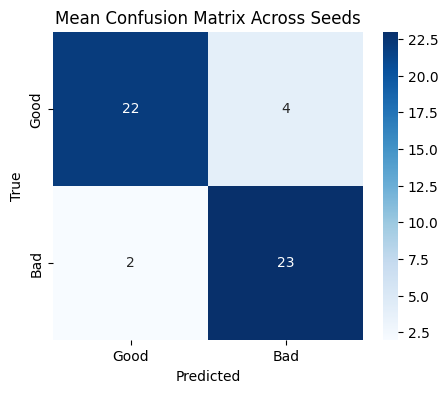

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Mean Confusion Matrix Across Seeds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ["Good", "Bad"])
plt.yticks([0.5, 1.5], ["Good", "Bad"])
plt.show()


# Permutation Feature Importance

2/2 [==============================] - 0s 198ms/step


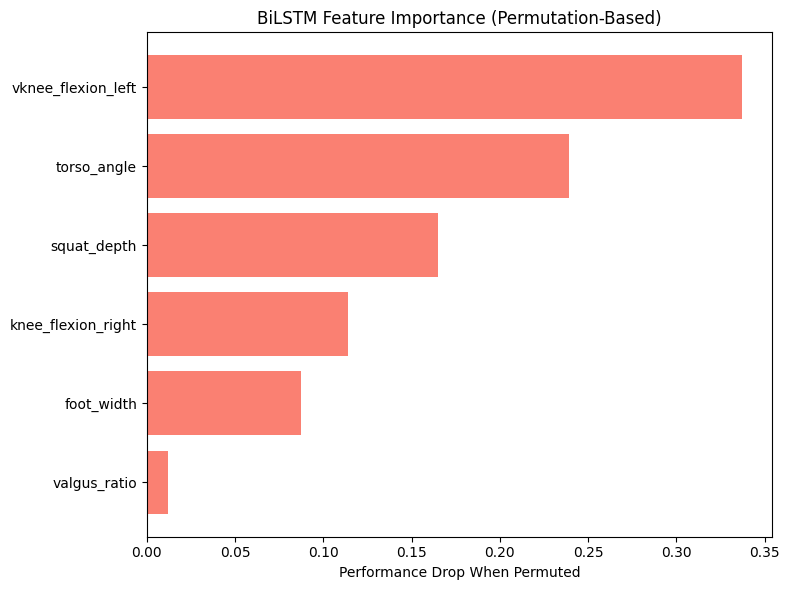

In [12]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

feature_names = ["vknee_flexion_left", "knee_flexion_right", "valgus_ratio", "torso_angle", "squat_depth", "foot_width"]
all_importances = []

# Augmenter class assumed to be imported and available
augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)

for seed in seeds:
    set_seed(seed)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )

    X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seed)

    # Train model
    model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))
    model = model_builder(lstm_units=96, dropout_rate=0.3, learning_rate=0.0003)
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    # Get original score
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    base_acc = accuracy_score(y_test, y_pred)

    importances = []
    for i in range(X_test.shape[2]):
        X_test_perm = X_test.copy()
        for t in range(X_test.shape[1]):
            np.random.shuffle(X_test_perm[:, t, i])  # shuffle the i-th feature across all samples at time t

        y_pred_perm = (model.predict(X_test_perm) > 0.5).astype(int)
        perm_acc = accuracy_score(y_test, y_pred_perm)
        importance = base_acc - perm_acc
        importances.append(importance)

    all_importances.append(importances)

# Average across seeds
mean_importance = np.mean(np.stack(all_importances), axis=0)

# Plot
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Permutation Drop": mean_importance
}).sort_values(by="Mean Permutation Drop", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(shap_df["Feature"][::-1], shap_df["Mean Permutation Drop"][::-1], color="salmon")
plt.xlabel("Performance Drop When Permuted")
plt.title("BiLSTM Feature Importance (Permutation-Based)")
plt.tight_layout()
plt.show()
